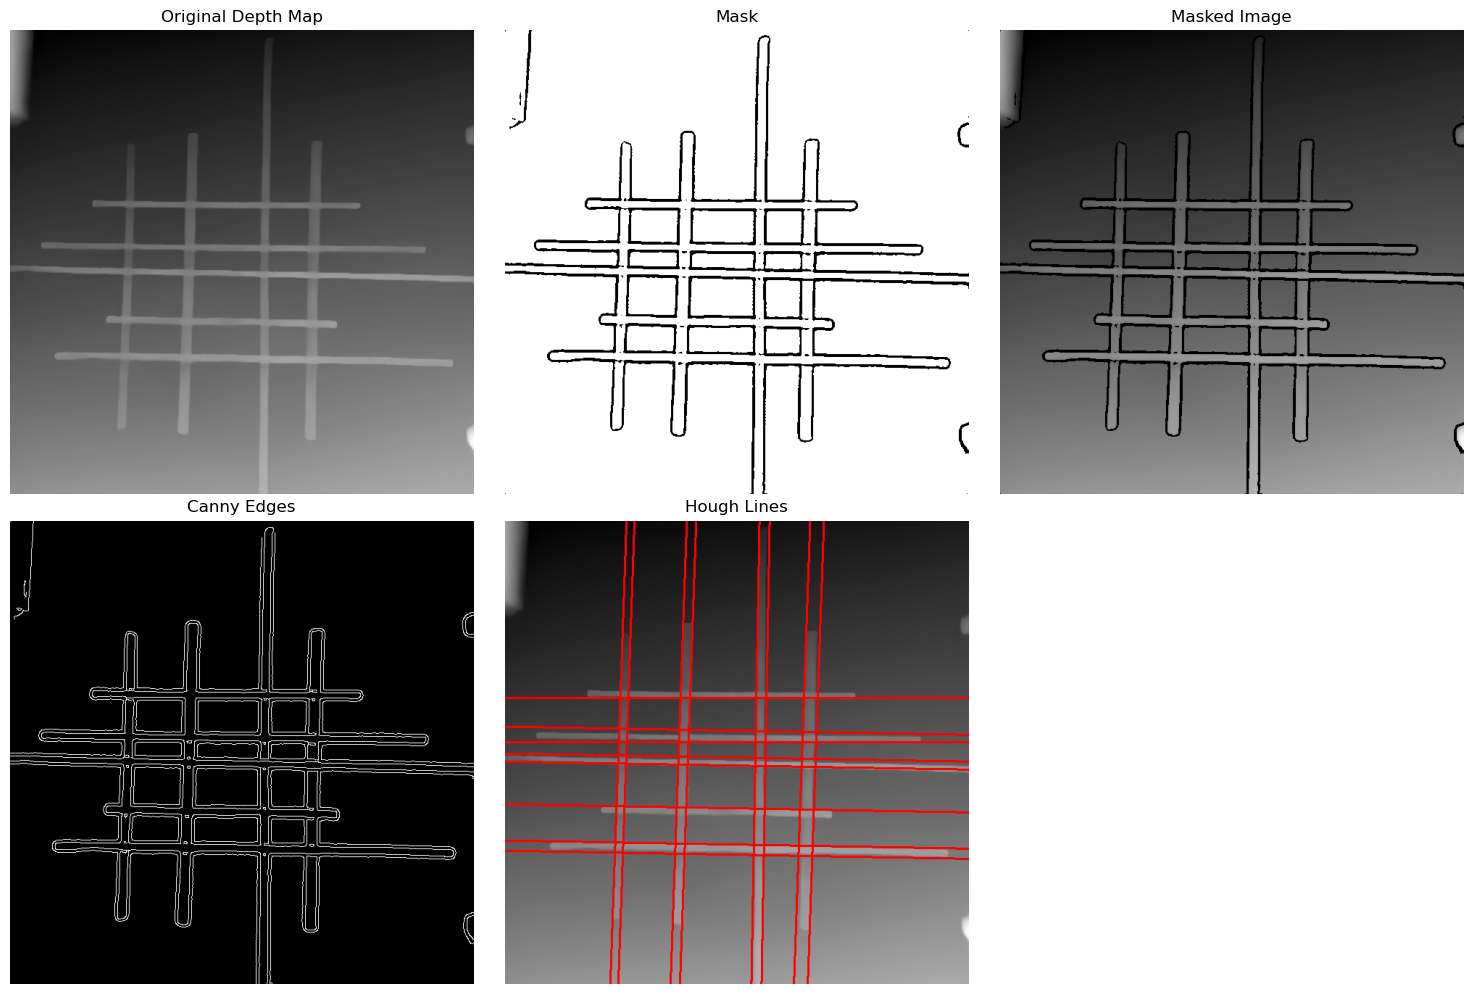

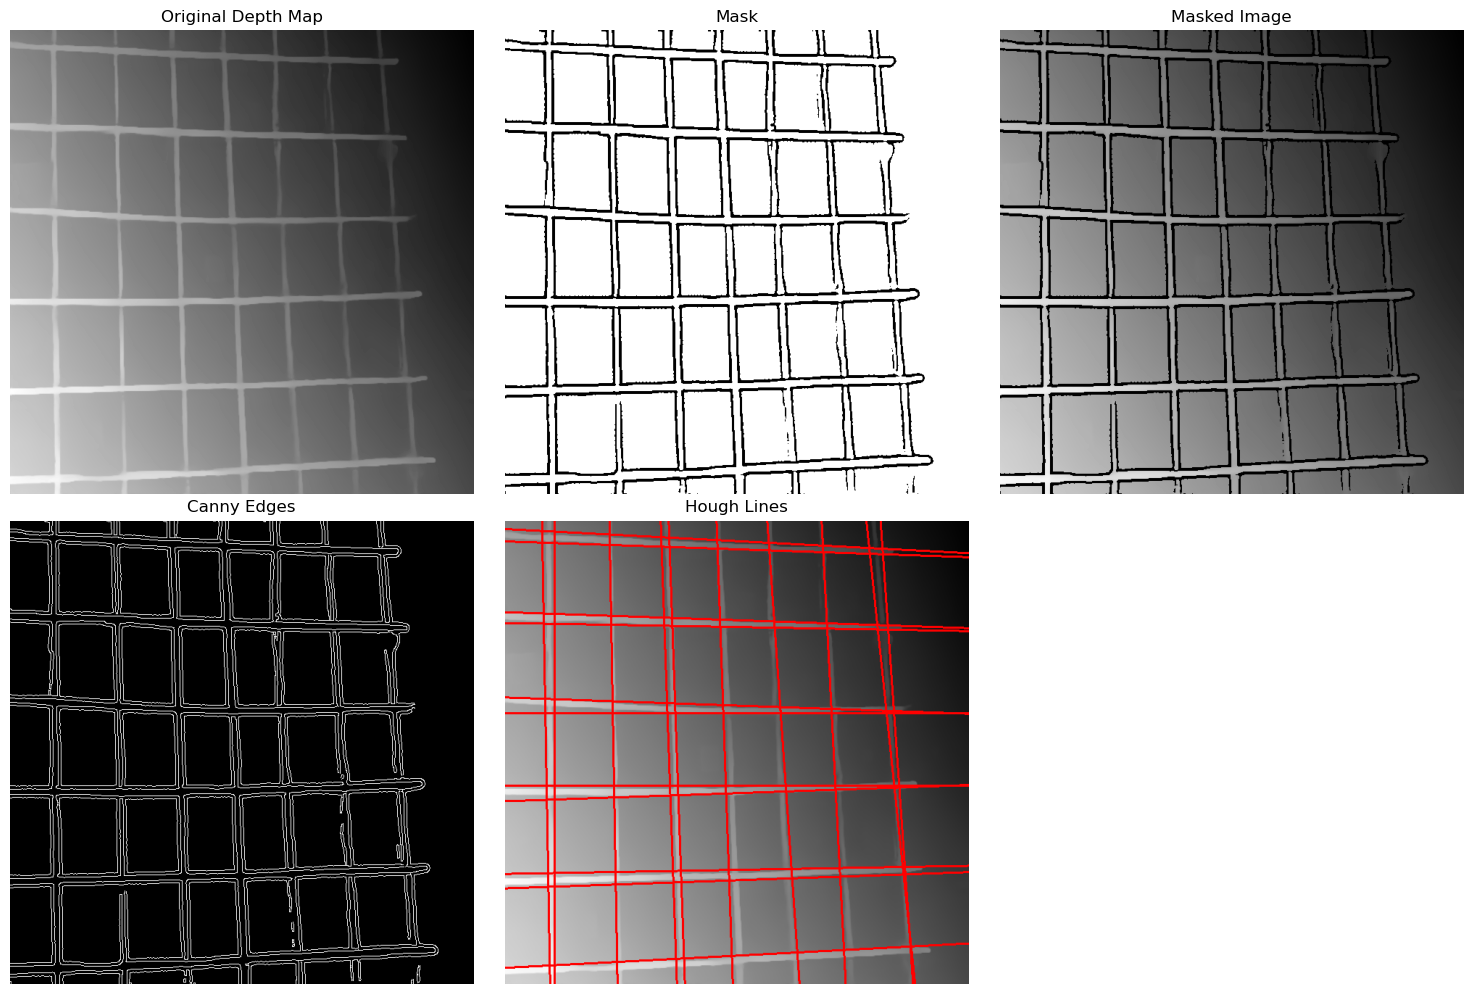

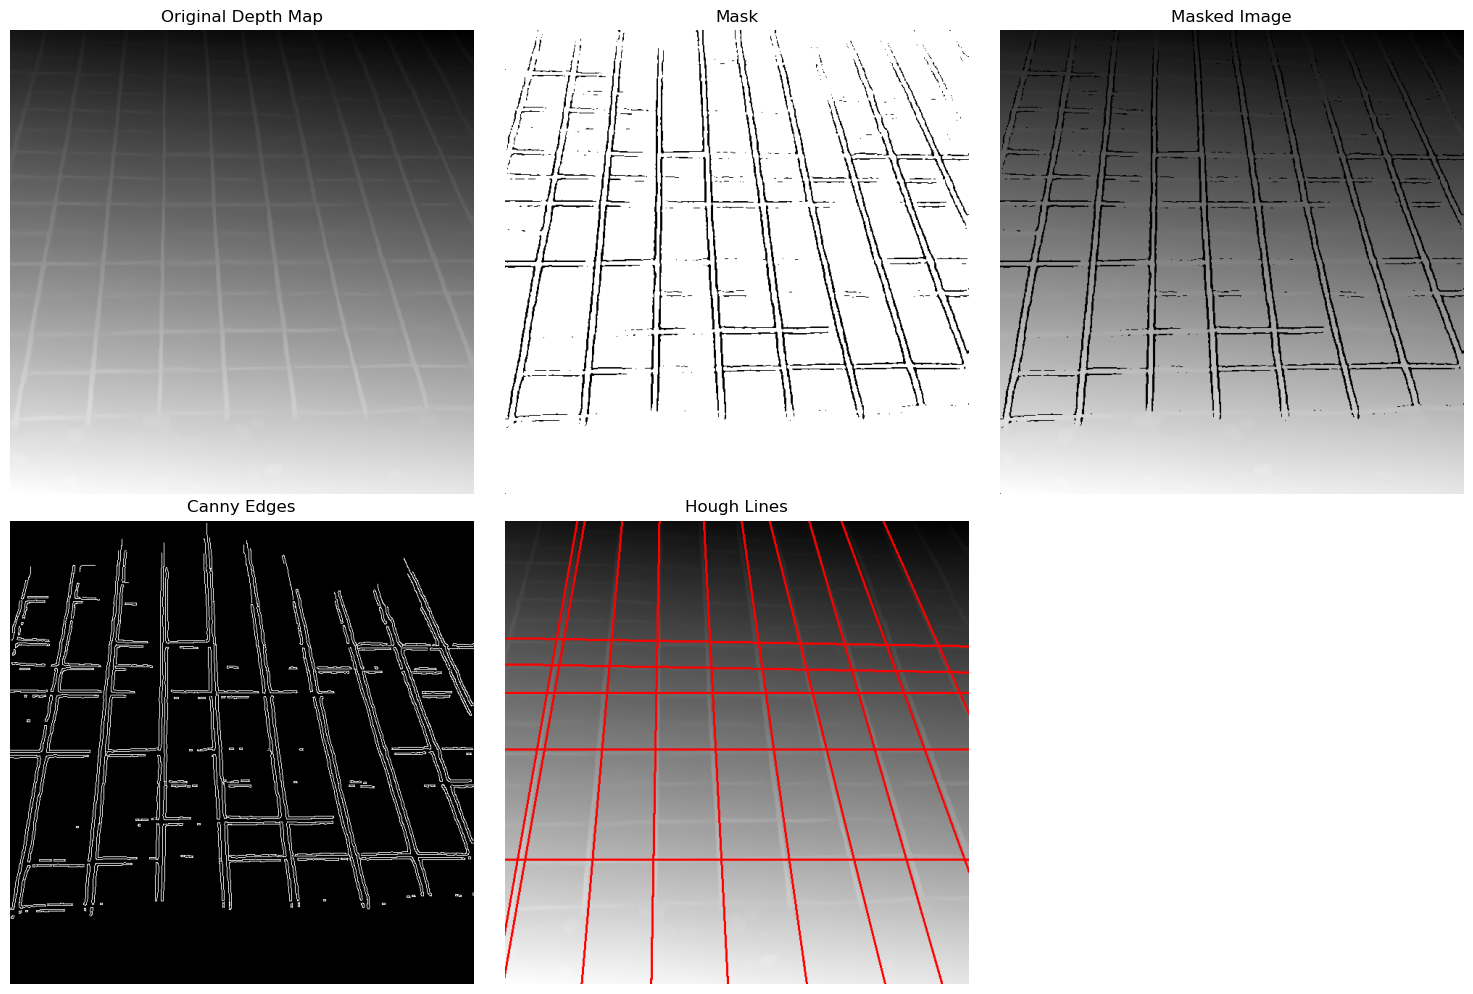

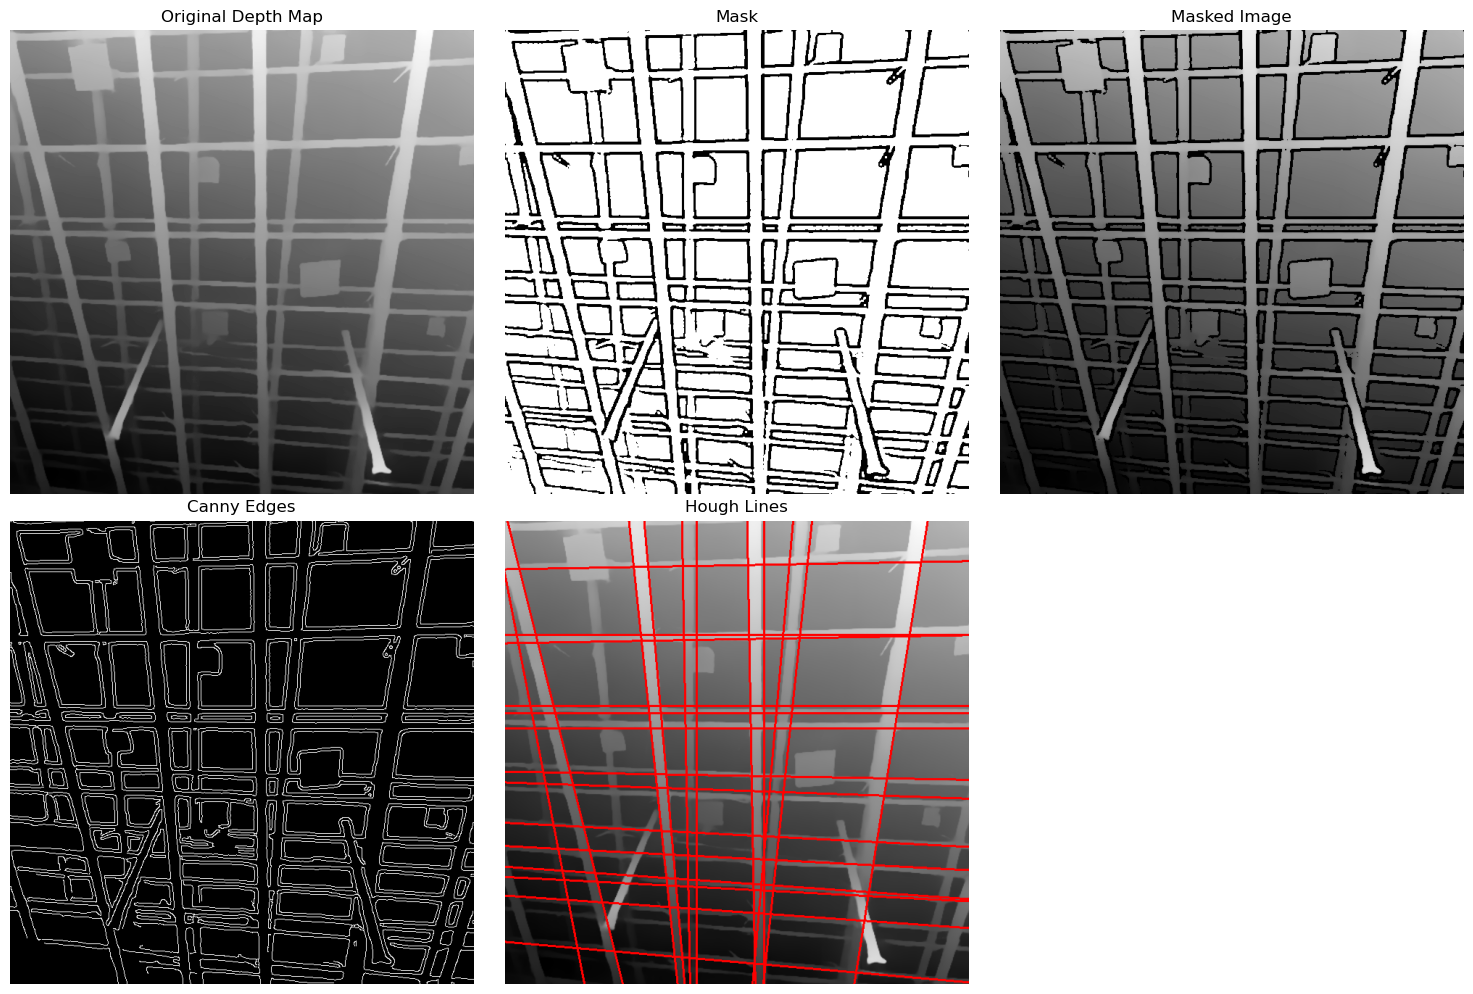

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import hough_line, hough_line_peaks

def apply_hough_transform_with_mask(image_path):
    """
    Apply Hough transform to detect lines in a depth map image after masking
    """
    # Load the depth map image
    depth_image = cv2.imread(image_path)
    if depth_image is None:
        print(f"Error: Could not load image from {image_path}")
        return
    
    # Convert to grayscale if needed
    if len(depth_image.shape) == 3:
        gray = cv2.cvtColor(depth_image, cv2.COLOR_BGR2GRAY)
    else:
        gray = depth_image.copy()
    
    # Create mask using adaptive thresholding
    mask = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    
    # Apply morphological operations to clean up the mask
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    # Apply mask to the image
    masked_image = cv2.bitwise_and(gray, gray, mask=mask)
    
    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(masked_image, (5, 5), 0)
    
    # Edge detection using Canny
    edges = cv2.Canny(blurred, 50, 150, apertureSize=3)
    
    # Perform Hough Transform
    hspace, angles, dists = hough_line(edges)

    # Find peaks
    accum, angles_peaks, dists_peaks = hough_line_peaks(hspace, angles, dists, threshold=0.5 * np.max(hspace))
    
    # Create result images
    result_standard = depth_image.copy()
    
    # Draw standard Hough lines
    if angles_peaks is not None:
        for rho, theta in zip(dists_peaks, angles_peaks):
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            cv2.line(result_standard, (x1, y1), (x2, y2), (0, 0, 255), 2)
    
    # Display results using matplotlib
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 3, 1)
    plt.imshow(gray, cmap='gray')
    plt.title('Original Depth Map')
    plt.axis('off')
    
    plt.subplot(2, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Mask')
    plt.axis('off')
    
    plt.subplot(2, 3, 3)
    plt.imshow(masked_image, cmap='gray')
    plt.title('Masked Image')
    plt.axis('off')
    
    plt.subplot(2, 3, 4)
    plt.imshow(edges, cmap='gray')
    plt.title('Canny Edges')
    plt.axis('off')
    
    plt.subplot(2, 3, 5)
    plt.imshow(cv2.cvtColor(result_standard, cv2.COLOR_BGR2RGB))
    plt.title('Hough Lines')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Apply to your specific image
image_path = '/Users/VISLAB/rebar-works/yolo-intersect-detection/data/depthmap/20250613_203702_jpg.rf.8a0542000d31483bd3869d89a7ec7bc0.png'
apply_hough_transform_with_mask(image_path)
image_path = "/Users/VISLAB/rebar-works/yolo-intersect-detection/data/depthmap/20250620_102446_jpg.rf.5f0144bd2e3a5c7fc82374b11d418e94.png"
apply_hough_transform_with_mask(image_path)
image_path = "/Users/VISLAB/rebar-works/yolo-intersect-detection/data/depthmap/20250620_114830_jpg.rf.5e2332d4c667c38b39dfc6d6839eddf1.png"
apply_hough_transform_with_mask(image_path)
image_path = "/Users/VISLAB/rebar-works/yolo-intersect-detection/data/depthmap/20250624_141044_jpg.rf.7c709c70d5afe1c016fa2bdf8249d489.png"
apply_hough_transform_with_mask(image_path)